# Figure 3c – Radial profiles of perturbed model maps

Reads `data/processed/figure_3c.csv` and saves `figures/figure_3c.png`.


In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import warnings
warnings.filterwarnings('ignore')
cwd = Path.cwd()
ROOT_DIR = cwd.parent if cwd.name == 'notebooks' else cwd
sys.path.insert(0, str(ROOT_DIR / 'notebooks'))
from plot_utils import setup_style, pretty_plot_radial_profile

PROCESSED = ROOT_DIR / 'data' / 'processed'
FIGURES   = ROOT_DIR / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

setup_style(font_scale=1.75)


In [3]:
df   = pd.read_csv(PROCESSED / 'figure_3c.csv')
freq = df['freq'].values
rmsd_cols = [c for c in df.columns if c.startswith('rmsd_')]
profiles  = [df[c].values for c in rmsd_cols]
# Build display labels: '0 A', '1 A', ...
labels = [c.replace('rmsd_', '').replace('A', r' $\AA$') for c in rmsd_cols]


Saved figures/figure_3c.png


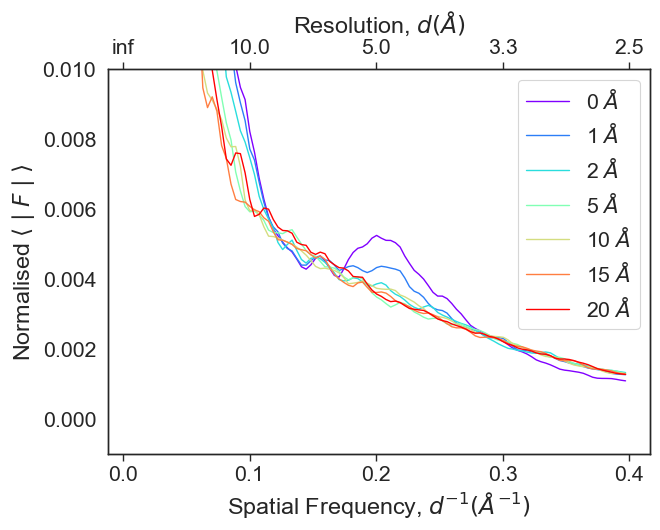

In [11]:
fig = pretty_plot_radial_profile(
    freq, profiles,
    legends=labels,
    logScale=False,
    normalise=True,
    crop_freq=[200,2.5],
    ylims=[-0.001,0.01],
    linewidth=1,
    figsize=(7, 5),
    fontscale=1.75,
)
fig.savefig(FIGURES / 'figure_3c.png', dpi=300, bbox_inches='tight', format='png')
print('Saved figures/figure_3c.png')
